# softmax回归的简洁实现
:label:`sec_softmax_concise`

在 :numref:`sec_linear_concise`中，
我们发现(**通过深度学习框架的高级API能够使实现**)
(~~softmax~~)
线性(**回归变得更加容易**)。
同样，通过深度学习框架的高级API也能更方便地实现softmax回归模型。
本节如在 :numref:`sec_softmax_scratch`中一样，
继续使用Fashion-MNIST数据集，并保持批量大小为256。


In [18]:
import torch
from torch import nn
from d2l import torch as d2l

In [19]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

## 初始化模型参数

如我们在 :numref:`sec_softmax`所述，
[**softmax回归的输出层是一个全连接层**]。
因此，为了实现我们的模型，
我们只需在`Sequential`中添加一个带有10个输出的全连接层。
同样，在这里`Sequential`并不是必要的，
但它是实现深度模型的基础。
我们仍然以均值0和标准差0.01随机初始化权重。


In [20]:
# PyTorch不会隐式地调整输入的形状。因此，
# 我们在线性层前定义了展平层（flatten），来调整网络输入的形状
net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights);

## 重新审视Softmax的实现
:label:`subsec_softmax-implementation-revisited`

在前面 :numref:`sec_softmax_scratch`的例子中，
我们计算了模型的输出，然后将此输出送入交叉熵损失。
从数学上讲，这是一件完全合理的事情。
然而，从计算角度来看，指数可能会造成数值稳定性问题。

回想一下，softmax函数$\hat y_j = \frac{\exp(o_j)}{\sum_k \exp(o_k)}$，
其中$\hat y_j$是预测的概率分布。
$o_j$是未规范化的预测$\mathbf{o}$的第$j$个元素。
如果$o_k$中的一些数值非常大，
那么$\exp(o_k)$可能大于数据类型容许的最大数字，即*上溢*（overflow）。
这将使分母或分子变为`inf`（无穷大），
最后得到的是0、`inf`或`nan`（不是数字）的$\hat y_j$。
在这些情况下，我们无法得到一个明确定义的交叉熵值。

解决这个问题的一个技巧是：
在继续softmax计算之前，先从所有$o_k$中减去$\max(o_k)$。
这里可以看到每个$o_k$按常数进行的移动不会改变softmax的返回值：

$$
\begin{aligned}
\hat y_j & =  \frac{\exp(o_j - \max(o_k))\exp(\max(o_k))}{\sum_k \exp(o_k - \max(o_k))\exp(\max(o_k))} \\
& = \frac{\exp(o_j - \max(o_k))}{\sum_k \exp(o_k - \max(o_k))}.
\end{aligned}
$$


在减法和规范化步骤之后，可能有些$o_j - \max(o_k)$具有较大的负值。
由于精度受限，$\exp(o_j - \max(o_k))$将有接近零的值，即*下溢*（underflow）。
这些值可能会四舍五入为零，使$\hat y_j$为零，
并且使得$\log(\hat y_j)$的值为`-inf`。
反向传播几步后，我们可能会发现自己面对一屏幕可怕的`nan`结果。

尽管我们要计算指数函数，但我们最终在计算交叉熵损失时会取它们的对数。
通过将softmax和交叉熵结合在一起，可以避免反向传播过程中可能会困扰我们的数值稳定性问题。
如下面的等式所示，我们避免计算$\exp(o_j - \max(o_k))$，
而可以直接使用$o_j - \max(o_k)$，因为$\log(\exp(\cdot))$被抵消了。

$$
\begin{aligned}
\log{(\hat y_j)} & = \log\left( \frac{\exp(o_j - \max(o_k))}{\sum_k \exp(o_k - \max(o_k))}\right) \\
& = \log{(\exp(o_j - \max(o_k)))}-\log{\left( \sum_k \exp(o_k - \max(o_k)) \right)} \\
& = o_j - \max(o_k) -\log{\left( \sum_k \exp(o_k - \max(o_k)) \right)}.
\end{aligned}
$$

我们也希望保留传统的softmax函数，以备我们需要评估通过模型输出的概率。
但是，我们没有将softmax概率传递到损失函数中，
而是[**在交叉熵损失函数中传递未规范化的预测，并同时计算softmax及其对数**]，
这是一种类似["LogSumExp技巧"](https://en.wikipedia.org/wiki/LogSumExp)的聪明方式。


In [21]:
loss = nn.CrossEntropyLoss(reduction='none')

## 优化算法

在这里，我们(**使用学习率为0.1的小批量随机梯度下降作为优化算法**)。
这与我们在线性回归例子中的相同，这说明了优化器的普适性。


In [22]:
trainer = torch.optim.SGD(net.parameters(), lr=0.1)

## 训练

接下来我们[**调用**] :numref:`sec_softmax_scratch`中(~~之前~~)
(**定义的训练函数来训练模型**)。


In [24]:
import torch
from torch import nn
from d2l import torch as d2l
from IPython import display

def evaluate_accuracy(net, data_iter):  #@save
    """计算在指定数据集上模型的精度"""
    if isinstance(net, torch.nn.Module):  #判断传入的 net 是否是 PyTorch 标准模型
        net.eval()  # 将模型设置为评估模式
        #评估模式，作用：
        # 关闭 Dropout、BatchNorm 的随机训练行为；
        # 保证测试时结果稳定，不引入随机噪声。
    metric = Accumulator(2)  # 正确预测数、预测总数 
                    #Accumulator(n)：自定义累加工具，创建长度为n的数组，持续累加数值。
    with torch.no_grad():
        #评估时不需要反向传播、不需要更新权重，关闭梯度可以：
        # 大幅节省显存、内存；
        # 提升推理计算速度。
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel())
            #net(X)：模型前向推理，输入批次数据 X，输出预测结果y_hat（二维概率矩阵）
            #accuracy(net(X), y)：调用你上一段的函数，返回当前批次预测正确的样本个数
            #y.numel()：numel() 是张量方法，返回张量总元素数量，即当前批次总样本数
            #metric.add(a,b)：累加器分别累加两个值：
            # metric[0] += a （正确样本数累加）
            # metric[1] += b （总样本数累加）
    return metric[0] / metric[1]
#@save
class Accumulator:
    """在n个变量上累加"""
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

#@save
def accuracy(y_hat, y):
    """计算预测正确的数量"""
    if len(y_hat.shape) > 1 and y_hat.size(1) > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

#@save
def train_epoch_ch3(net, train_iter, loss, updater):
    """训练模型一个迭代周期（定义见第3章）"""
    if isinstance(net, torch.nn.Module):
        net.train()
    metric = Accumulator(3)
    for X, y in train_iter:
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            l.sum().backward()
            updater(X.shape[0])
        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
    return metric[0] / metric[2], metric[1] / metric[2]

#@save
class Animator:
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        if legend is None:
            legend = []
        d2l.use_svg_display()
        self.fig, self.axes = d2l.plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        self.config_axes = lambda: d2l.set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

#@save
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):
    """训练模型（定义见第3章）"""
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0, 1],
                        legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics

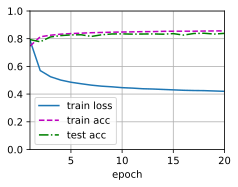

In [25]:
num_epochs = 20
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)  
##源代码是d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)  #
#没有上面一个代码cell，因新版没有内置函数，只能复制代码

In [26]:
import d2l
print(d2l.__version__)

import d2l.torch as d2l
print(dir(d2l))

1.0.3
['Accumulator', 'AddNorm', 'AdditiveAttention', 'Animator', 'AttentionDecoder', 'BERTEncoder', 'BERTModel', 'BananasDataset', 'BasicScheduler', 'Benchmark', 'Classifier', 'DATA_HUB', 'DATA_URL', 'DataModule', 'Decoder', 'DotProductAttention', 'Encoder', 'EncoderDecoder', 'F', 'FashionMNIST', 'GRU', 'HPOScheduler', 'HPOSearcher', 'HPOTrainer', 'HPOTuner', 'HyperParameters', 'Image', 'LeNet', 'LinearRegression', 'LinearRegressionScratch', 'MTFraEng', 'MaskLM', 'MaskedSoftmaxCELoss', 'Module', 'MultiHeadAttention', 'NextSentencePred', 'PositionWiseFFN', 'PositionalEncoding', 'ProgressBoard', 'RNN', 'RNNLM', 'RNNLMScratch', 'RNNScratch', 'RandomGenerator', 'RandomSearcher', 'ResNeXtBlock', 'Residual', 'SGD', 'SNLIDataset', 'Seq2Seq', 'Seq2SeqEncoder', 'SoftmaxRegression', 'SuccessiveHalvingScheduler', 'SyntheticRegressionData', 'TimeMachine', 'Timer', 'TokenEmbedding', 'Trainer', 'TransformerEncoder', 'TransformerEncoderBlock', 'VOCSegDataset', 'VOC_CLASSES', 'VOC_COLORMAP', 'Vocab',

In [27]:
from d2l import torch as d2l
##由于更新，包丢了
print(d2l.__name__)
print(hasattr(d2l, 'train_ch3'))
print(hasattr(d2l, 'train_epoch_ch3'))
print(hasattr(d2l, 'evaluate_accuracy'))
print(hasattr(d2l, 'add'))


d2l.torch
False
False
False
False


In [28]:
names = [
    name for name in dir(d2l)
    if "train" in name.lower() or "accuracy" in name.lower()
]

print(names)

['HPOTrainer', 'Trainer', 'accuracy', 'evaluate_accuracy_gpu', 'reorg_train_valid', 'train_2d', 'train_batch_ch13', 'train_ch11', 'train_ch13', 'train_ch6', 'train_concise_ch11', 'train_seq2seq']


In [29]:
import sys

print("Python版本：", sys.version)
print("Python位置：", sys.executable)

Python版本： 3.8.20 (default, Oct  3 2024, 15:24:27) 
[GCC 11.2.0]
Python位置： /home/Fate-Linux/miniconda3/envs/LimuDeeplearning_py3.8/bin/python


In [30]:
import os

print("Notebook当前目录：", os.getcwd())

Notebook当前目录： /home/Fate-Linux/github_connection/Limu_deeplearning_myselfnotebook/chapter_linear-networks


In [31]:
import d2l

print("d2l文件位置：", d2l.__file__)

d2l文件位置： /home/Fate-Linux/miniconda3/envs/LimuDeeplearning_py3.8/lib/python3.8/site-packages/d2l/__init__.py


In [32]:
%pip show d2l

Name: d2l
Version: 1.0.3
Summary: Dive into Deep Learning
Home-page: https://d2l.ai
Author: D2L Developers
Author-email: d2l.devs@gmail.com
License: MIT-0
Location: /home/Fate-Linux/miniconda3/envs/LimuDeeplearning_py3.8/lib/python3.8/site-packages
Requires: jupyter, matplotlib, matplotlib-inline, numpy, pandas, requests, scipy
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [33]:
import torch

print("PyTorch版本：", torch.__version__)
print("CUDA是否可用：", torch.cuda.is_available())

PyTorch版本： 2.4.1+cu121
CUDA是否可用： True


In [66]:
from pathlib import Path

repo_root = Path.cwd().parent
package_dir = repo_root / "myd2l"

package_dir.mkdir(exist_ok=True)

print("仓库根目录：", repo_root)
print("自定义包目录：", package_dir)
print("目录是否存在：", package_dir.exists())

仓库根目录： /home/Fate-Linux/github_connection/Limu_deeplearning_myselfnotebook
自定义包目录： /home/Fate-Linux/github_connection/Limu_deeplearning_myselfnotebook/myd2l
目录是否存在： True


In [82]:
%%writefile ../myd2l/compatibility.py

import torch
import torch
from d2l import torch as d2l
from IPython import display

class Accumulator:
    """在n个变量上累加"""
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]
      
# def accuracy(y_hat, y):
#     """统计预测正确的样本数量。"""
#     if y_hat.ndim > 1 and y_hat.shape[1] > 1:
#         y_hat = y_hat.argmax(dim=1)

#     comparison = y_hat.to(y.dtype) == y
#     return float(comparison.to(torch.float32).sum())


def accuracy(y_hat, y):
    """计算预测正确的数量"""
    if len(y_hat.shape) > 1 and y_hat.size(1) > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

# def evaluate_accuracy(net, data_iter):
#     """计算模型在数据集上的准确率。"""
#     if isinstance(net, torch.nn.Module):
#         net.eval()

#     correct = 0.0
#     total = 0

#     with torch.no_grad():
#         for X, y in data_iter:
#             y_hat = net(X)
#             correct += accuracy(y_hat, y)
#             total += y.numel()

#     return correct / total
def evaluate_accuracy(net, data_iter):  #@save
    """计算在指定数据集上模型的精度"""
    if isinstance(net, torch.nn.Module):  #判断传入的 net 是否是 PyTorch 标准模型
        net.eval()  # 将模型设置为评估模式
        #评估模式，作用：
        # 关闭 Dropout、BatchNorm 的随机训练行为；
        # 保证测试时结果稳定，不引入随机噪声。
    metric = Accumulator(2)  # 正确预测数、预测总数 
                    #Accumulator(n)：自定义累加工具，创建长度为n的数组，持续累加数值。
    with torch.no_grad():
        #评估时不需要反向传播、不需要更新权重，关闭梯度可以：
        # 大幅节省显存、内存；
        # 提升推理计算速度。
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel())
            #net(X)：模型前向推理，输入批次数据 X，输出预测结果y_hat（二维概率矩阵）
            #accuracy(net(X), y)：调用你上一段的函数，返回当前批次预测正确的样本个数
            #y.numel()：numel() 是张量方法，返回张量总元素数量，即当前批次总样本数
            #metric.add(a,b)：累加器分别累加两个值：
            # metric[0] += a （正确样本数累加）
            # metric[1] += b （总样本数累加）
    return metric[0] / metric[1]

class Animator:
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        if legend is None:
            legend = []
        d2l.use_svg_display()
        self.fig, self.axes = d2l.plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        self.config_axes = lambda: d2l.set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)
def train_epoch_ch3(net, train_iter, loss, updater):
    """训练模型一个迭代周期（定义见第3章）"""
    if isinstance(net, torch.nn.Module):
        net.train()
    metric = Accumulator(3)
    for X, y in train_iter:
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            l.sum().backward()
            updater(X.shape[0])
        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
    return metric[0] / metric[2], metric[1] / metric[2]

#@save
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):
    """训练模型（定义见第3章）"""
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0, 1],
                        legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics

Overwriting ../myd2l/compatibility.py


In [83]:
compatibility_file = package_dir / "compatibility.py"

print("文件位置：", compatibility_file)
print("文件是否存在：", compatibility_file.exists())

文件位置： /home/Fate-Linux/github_connection/Limu_deeplearning_myselfnotebook/myd2l/compatibility.py
文件是否存在： True


In [84]:
%%writefile ../myd2l/__init__.py

from .compatibility import accuracy
from .compatibility import evaluate_accuracy
from .compatibility import train_epoch_ch3
from .compatibility import train_ch3
from .compatibility import Animator

__all__ = [
    "accuracy",
    "evaluate_accuracy",
    "train_epoch_ch3",
    "train_ch3",
    "Animator"
]

Overwriting ../myd2l/__init__.py


In [85]:
from pathlib import Path
import myd2l

print("当前导入的myd2l位置：")
print(myd2l.__file__)

print("\n当前__init__.py内容：")
print(Path(myd2l.__file__).read_text(encoding="utf-8"))

当前导入的myd2l位置：
/home/Fate-Linux/github_connection/Limu_deeplearning_myselfnotebook/myd2l/__init__.py

当前__init__.py内容：

from .compatibility import accuracy
from .compatibility import evaluate_accuracy
from .compatibility import train_epoch_ch3
from .compatibility import train_ch3
from .compatibility import Animator

__all__ = [
    "accuracy",
    "evaluate_accuracy",
    "train_epoch_ch3",
    "train_ch3",
    "Animator"
]



In [86]:
import sys

repo_path = str(repo_root)

if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

print("仓库是否已加入搜索路径：", repo_path in sys.path)

仓库是否已加入搜索路径： True


In [87]:
# import d2l.torch as d2l
# print(dir(d2l))
import myd2l
print(dir(myd2l))
# print("myd2l位置：", myd2l.__file__)
# print("是否有accuracy：", hasattr(myd2l, "accuracy"))
# print("是否有evaluate_accuracy：", hasattr(myd2l, "evaluate_accuracy"))

['Animator', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'accuracy', 'compatibility', 'evaluate_accuracy', 'train_ch3', 'train_epoch_ch3']


In [88]:
from pathlib import Path

file_path = Path("../myd2l/compatibility.py").resolve()

print("文件位置：", file_path)
print("文件存在：", file_path.exists())
print("文件大小：", file_path.stat().st_size, "字节")

文件位置： /home/Fate-Linux/github_connection/Limu_deeplearning_myselfnotebook/myd2l/compatibility.py
文件存在： True
文件大小： 5267 字节


In [89]:
import importlib
import myd2l
import myd2l.compatibility

# 先重新加载真正定义函数的文件
importlib.reload(myd2l.compatibility)

# 再重新加载包入口
importlib.reload(myd2l)

print("是否有train_ch3：", hasattr(myd2l, "train_ch3"))
print("是否有train_epoch_ch3：", hasattr(myd2l, "train_epoch_ch3"))
print("是否有Animator：", hasattr(myd2l, "Animator"))

是否有train_ch3： True
是否有train_epoch_ch3： True
是否有Animator： True


In [90]:
from pathlib import Path
import ast

compatibility_file = Path("../myd2l/compatibility.py").resolve()
source_code = compatibility_file.read_text(encoding="utf-8")
syntax_tree = ast.parse(source_code)

top_level_names = []

for node in syntax_tree.body:
    if isinstance(node, (ast.FunctionDef, ast.ClassDef)):
        top_level_names.append(
            (node.__class__.__name__, node.name, node.lineno)
        )

print("文件位置：", compatibility_file)
print("顶层定义：")

for item_type, name, line_number in top_level_names:
    print(f"{item_type}: {name}，第{line_number}行")

文件位置： /home/Fate-Linux/github_connection/Limu_deeplearning_myselfnotebook/myd2l/compatibility.py
顶层定义：
ClassDef: Accumulator，第7行
FunctionDef: accuracy，第30行
FunctionDef: evaluate_accuracy，第52行
ClassDef: Animator，第75行
FunctionDef: train_epoch_ch3，第111行
FunctionDef: train_ch3，第130行


In [91]:
#清除 Jupyter 中的旧缓存，然后重新导入
import sys
import importlib
from pathlib import Path

# 确保仓库根目录位于Python搜索路径中
repo_root = str(Path.cwd().parent)

if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

# 删除旧模块缓存
sys.modules.pop("myd2l.compatibility", None)
sys.modules.pop("myd2l", None)

# 让Python重新检查文件
importlib.invalidate_caches()

# 重新导入
import myd2l

print("myd2l位置：", myd2l.__file__)
print("是否有accuracy：", hasattr(myd2l, "accuracy"))
print("是否有evaluate_accuracy：", hasattr(myd2l, "evaluate_accuracy"))
print("是否有train_epoch_ch3：", hasattr(myd2l, "train_epoch_ch3"))
print("是否有train_ch3：", hasattr(myd2l, "train_ch3"))
print("是否有Animator：", hasattr(myd2l, "Animator"))

myd2l位置： /home/Fate-Linux/github_connection/Limu_deeplearning_myselfnotebook/myd2l/__init__.py
是否有accuracy： True
是否有evaluate_accuracy： True
是否有train_epoch_ch3： True
是否有train_ch3： True
是否有Animator： True


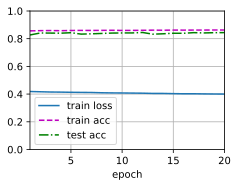

In [92]:
num_epochs = 20
myd2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)  

In [93]:
#仅仅创建 myd2l 文件夹时，如果 Notebook 位于其他章节的子目录中，Python 不一定能找到它。
#因此我们稍后会在仓库根目录添加 pyproject.toml，然后在当前 Notebook 中执行一次：
%pip install -e /home/Fate-Linux/github_connection/Limu_deeplearning_myselfnotebook

Obtaining file:///home/Fate-Linux/github_connection/Limu_deeplearning_myselfnotebook
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of jupyterlab-server to determine which version is compatible with other requirements. This could take a while.
  Using cached jupyterlab-4.3.8-py3-none-any.whl.metadata (16 kB)
INFO: pip is still looking at multiple versions of jupyterlab-server to determine which version is compatible with other requirements. This could take a while.
  Using cached notebook-7.4.7-py3-none-any.whl.metadata (10 kB)
INFO: pip is looking at multiple versions of notebook to determine which version is compatible with other requirements. This could take a while.
  Using cached notebook-7.4.6-py3-none-any.whl.metadata (10 kB)
  Using cached notebook-7.4.5-py3-none-any.whl.metadata (10 kB)
  Using cached notebook-7.4.4-py3-none-any.whl.metadata (10 kB)
  Using cached notebook-7.4.3-py3-none-any.whl.metadata (10 kB)
  Using cached notebook-7.4.2

In [94]:
%pip install --no-deps \
    numpy==1.23.5 \
    pandas==2.0.3 \
    matplotlib==3.7.2 \
    requests==2.31.0 \
    jupyter-client==8.6.3 \
    notebook==7.3.3

  Using cached numpy-1.23.5-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.3 kB)
  Using cached pandas-2.0.3-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
  Using cached matplotlib-3.7.2-cp38-cp38-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (5.6 kB)
  Using cached requests-2.31.0-py3-none-any.whl.metadata (4.6 kB)
  Using cached jupyter_client-8.6.3-py3-none-any.whl.metadata (8.3 kB)
  Using cached notebook-7.3.3-py3-none-any.whl.metadata (10 kB)
Using cached numpy-1.23.5-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.1 MB)
Using cached pandas-2.0.3-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.4 MB)
Using cached matplotlib-3.7.2-cp38-cp38-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (9.2 MB)
Using cached requests-2.31.0-py3-none-any.whl (62 kB)
Using cached jupyter_client-8.6.3-py3-none-any.whl (106 kB)
Using cached notebook-7.3.3-py3-none-any.whl (13.1 MB)
  Attempting uninstall: requests
   

In [1]:
import numpy
import pandas
import matplotlib
import requests
import jupyter_client
import d2l

print("NumPy：", numpy.__version__)
print("Pandas：", pandas.__version__)
print("Matplotlib：", matplotlib.__version__)
print("Requests：", requests.__version__)
print("Jupyter Client：", jupyter_client.__version__)
print("d2l位置：", d2l.__file__)

NumPy： 1.23.5
Pandas： 2.0.3
Matplotlib： 3.7.2
Requests： 2.31.0
Jupyter Client： 8.6.3
d2l位置： /home/Fate-Linux/miniconda3/envs/LimuDeeplearning_py3.8/lib/python3.8/site-packages/d2l/__init__.py


In [2]:
#仓库原有的 setup.py 会与官方 d2l 冲突。
#我们改用更安全、适合初学者的方式：让当前 Conda 环境直接认识你的仓库目录
from pathlib import Path
import site

repo_root = Path(
    "/home/Fate-Linux/github_connection/Limu_deeplearning_myselfnotebook"
)

site_packages = Path(site.getsitepackages()[0])
path_file = site_packages / "myd2l_repo.pth"

path_file.write_text(str(repo_root) + "\n", encoding="utf-8")

print("仓库目录：", repo_root)
print("路径配置文件：", path_file)
print("配置内容：", path_file.read_text())

仓库目录： /home/Fate-Linux/github_connection/Limu_deeplearning_myselfnotebook
路径配置文件： /home/Fate-Linux/miniconda3/envs/LimuDeeplearning_py3.8/lib/python3.8/site-packages/myd2l_repo.pth
配置内容： /home/Fate-Linux/github_connection/Limu_deeplearning_myselfnotebook



In [1]:
from pathlib import Path
import site
#这里的 .pth 文件相当于告诉当前 Conda 环境：
#导入 Python 包时，也去这个 GitHub 仓库中查找
repo_root = Path(
    "/home/Fate-Linux/github_connection/Limu_deeplearning_myselfnotebook"
)

site_packages = Path(site.getsitepackages()[0])
path_file = site_packages / "myd2l_repo.pth"

path_file.write_text(str(repo_root) + "\n", encoding="utf-8")

print("仓库目录：", repo_root)
print("路径配置文件：", path_file)
print("配置内容：", path_file.read_text())

仓库目录： /home/Fate-Linux/github_connection/Limu_deeplearning_myselfnotebook
路径配置文件： /home/Fate-Linux/miniconda3/envs/LimuDeeplearning_py3.8/lib/python3.8/site-packages/myd2l_repo.pth
配置内容： /home/Fate-Linux/github_connection/Limu_deeplearning_myselfnotebook



In [1]:
import myd2l

print("myd2l位置：", myd2l.__file__)

myd2l位置： /home/Fate-Linux/github_connection/Limu_deeplearning_myselfnotebook/myd2l/__init__.py


In [2]:
import myd2l as md2l

functions_to_check = [
    "accuracy",
    "evaluate_accuracy",
    "train_epoch_ch3",
    "train_ch3",
]

print("myd2l位置：", md2l.__file__)
print("\n函数检查结果：")

for function_name in functions_to_check:
    exists = hasattr(md2l, function_name)
    status = "✅ 已补全" if exists else "❌ 尚未补全"
    print(f"{function_name}: {status}")

myd2l位置： /home/Fate-Linux/github_connection/Limu_deeplearning_myselfnotebook/myd2l/__init__.py

函数检查结果：
accuracy: ✅ 已补全
evaluate_accuracy: ✅ 已补全
train_epoch_ch3: ✅ 已补全
train_ch3: ✅ 已补全


In [3]:
import importlib
import myd2l as md2l

importlib.reload(md2l)
for function_name in functions_to_check:
    function = getattr(md2l, function_name, None)
    print(
        function_name,
        "存在：", function is not None,
        "可以调用：", callable(function)
    )

accuracy 存在： True 可以调用： True
evaluate_accuracy 存在： True 可以调用： True
train_epoch_ch3 存在： True 可以调用： True
train_ch3 存在： True 可以调用： True


和以前一样，这个算法使结果收敛到一个相当高的精度，而且这次的代码比之前更精简了。

## 小结

* 使用深度学习框架的高级API，我们可以更简洁地实现softmax回归。
* 从计算的角度来看，实现softmax回归比较复杂。在许多情况下，深度学习框架在这些著名的技巧之外采取了额外的预防措施，来确保数值的稳定性。这使我们避免了在实践中从零开始编写模型时可能遇到的陷阱。

## 练习

1. 尝试调整超参数，例如批量大小、迭代周期数和学习率，并查看结果。
1. 增加迭代周期的数量。为什么测试精度会在一段时间后降低？我们怎么解决这个问题？


[Discussions](https://discuss.d2l.ai/t/1793)
